In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# **(1) Download & Clean Meteorological Climate Station Data**

### Start by finding list of relevent weather stations in Alberta and BC

In [ ]:
# Load and check Station Inventory CSV file
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df_stations = pd.read_csv('/content/drive/MyDrive/MDP_Capstone_Project/Data/Station_Inventory.csv', skiprows=3)

# Check the column names to confirm formatting
print(df_stations.columns)
df_stations.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Index(['Name', 'Province', 'Climate ID', 'Station ID', 'WMO ID', 'TC ID',
       'Latitude (Decimal Degrees)', 'Longitude (Decimal Degrees)', 'Latitude',
       'Longitude', 'Elevation (m)', 'First Year', 'Last Year',
       'HLY First Year', 'HLY Last Year', 'DLY First Year', 'DLY Last Year',
       'MLY First Year', 'MLY Last Year'],
      dtype='object')


,Name,Province,Climate ID,Station ID,WMO ID,TC ID,Latitude (Decimal Degrees),Longitude (Decimal Degrees),Latitude,Longitude,Elevation (m),First Year,Last Year,HLY First Year,HLY Last Year,DLY First Year,DLY Last Year,MLY First Year,MLY Last Year
0,ACTIVE PASS,BRITISH COLUMBIA,1010066,14,NaN,NaN,48.87,-123.28,485200000,-1231700000,4.0,1984,1996,NaN,NaN,1984.0,1996.0,1984.0,1996.0
1,ALBERT HEAD,BRITISH COLUMBIA,1010235,15,NaN,NaN,48.40,-123.48,482400000,-1232900000,17.0,1971,1995,NaN,NaN,1971.0,1995.0,1971.0,1995.0
2,BAMBERTON OCEAN CEMENT,BRITISH COLUMBIA,1010595,16,NaN,NaN,48.58,-123.52,483500000,-1233100000,85.3,1961,1980,NaN,NaN,1961.0,1980.0,1961.0,1980.0
3,BEAR CREEK,BRITISH COLUMBIA,1010720,17,NaN,NaN,48.50,-124.00,483000000,-1240000000,350.5,1910,1971,NaN,NaN,1910.0,1971.0,1910.0,1971.0
4,BEAVER LAKE,BRITISH COLUMBIA,1010774,18,NaN,NaN,48.50,-123.35,483000000,-1232100000,61.0,1894,1952,NaN,NaN,1894.0,1952.0,1894.0,1952.0


### Filter for stations in Alberta & BC with any daily coverage between 2014 and 2024

In [ ]:
df_ab_bc = df_stations[
    df_stations['Province'].isin(['ALBERTA', 'BRITISH COLUMBIA']) &
    (df_stations['DLY First Year'] <= 2024) &
    (df_stations['DLY Last Year'] >= 2014)
]

print(df_ab_bc.shape)
print(df_ab_bc['Province'].value_counts())
print(df_ab_bc[['Name', 'Province', 'Climate ID', 'DLY First Year', 'DLY Last Year']].head())


(653, 19)
Province
BRITISH COLUMBIA    343
ALBERTA             310
Name: count, dtype: int64
                      Name          Province Climate ID  DLY First Year  \
12               CHEMAINUS  BRITISH COLUMBIA    1011500          1919.0   
23  COWICHAN LAKE FORESTRY  BRITISH COLUMBIA    1012040          1949.0   
26           LAKE COWICHAN  BRITISH COLUMBIA    1012055          1960.0   
28        DISCOVERY ISLAND  BRITISH COLUMBIA    1012475          1997.0   
33     DUNCAN KELVIN CREEK  BRITISH COLUMBIA    1012573          1987.0   

    DLY Last Year  
12         2024.0  
23         2018.0  
26         2025.0  
28         2025.0  
33         2016.0  


### Download daily weather data for stations in Alberta & BC with any daily coverage between 2014 and 2024

In [ ]:
import pandas as pd
import requests
import os

# Identify years that need to be downloaded
years = list(range(2014, 2025))

# Create output folder
output_dir = '/content/drive/MyDrive/MDP_Capstone_Project/Data/daily_weather'
os.makedirs(output_dir, exist_ok=True)

# Change full province names to code
def province_to_code(province):
    return {
        'BRITISH COLUMBIA': 'BC',
        'ALBERTA': 'AB'
    }.get(province.upper(), None)

# Filter for AB and BC stations withat least some daily data from 2014 to 2024
filtered = df_stations[
    (df_stations['Province'].isin(['BRITISH COLUMBIA', 'ALBERTA'])) &
    (df_stations['DLY First Year'] <= 2024) &
    (df_stations['DLY Last Year'] >= 2014)
].copy()

# Create summary of station availability by province and year
availability = []

for _, row in filtered.iterrows():
    province = row['Province']
    first_year = int(row['DLY First Year'])
    last_year = int(row['DLY Last Year'])

    for year in range(2014, 2025):
        if first_year <= year <= last_year:
            availability.append({'Province': province, 'Year': year})

# Convert to Dataframe
df_avail = pd.DataFrame(availability)

# Group and count available stations by year and province
summary = df_avail.groupby(['Province', 'Year']).size().unstack(fill_value=0)
print(summary)

# Loop through and download daily weather data from relevent stations
for _, row in filtered.iterrows():
    name = row['Name']
    prov_code = province_to_code(row['Province'])
    if prov_code is None:
        continue

    station_id = str(row['Climate ID']).zfill(7)
    first_year = int(row['DLY First Year'])
    last_year = int(row['DLY Last Year'])

    for yr in years:
        if yr < first_year or yr > last_year:
            continue

        filename = f'climate_daily_{prov_code}_{station_id}_{yr}_P1D.csv'
        url = f'https://dd.weather.gc.ca/climate/observations/daily/csv/{prov_code}/{filename}'
        out_path = os.path.join(output_dir, f'{prov_code}_{station_id}_{yr}.csv')

        # Skip if already downloaded
        if os.path.exists(out_path):
            continue

        try:
            resp = requests.get(url)
            if resp.status_code == 200:
                with open(out_path, 'wb') as f:
                    f.write(resp.content)
            else:
                print(f'Failed: {filename} (status {resp.status_code})')
        except Exception as e:
            print(f'Error downloading {filename} for station {name}: {e}')

Year              2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  \
Province                                                                       
ALBERTA            253   245   241   233   279   273   273   273   270   268   
BRITISH COLUMBIA   305   301   291   278   279   270   270   262   255   251   

Year              2024  
Province                
ALBERTA            263  
BRITISH COLUMBIA   241  
Failed: climate_daily_BC_1108425_2014_P1D.csv (status 404)
Failed: climate_daily_BC_1183007_2014_P1D.csv (status 404)
Failed: climate_daily_AB_3062475_2016_P1D.csv (status 404)
Failed: climate_daily_AB_306A009_2022_P1D.csv (status 404)
Failed: climate_daily_AB_306A009_2023_P1D.csv (status 404)
Failed: climate_daily_AB_306A009_2024_P1D.csv (status 404)
Failed: climate_daily_AB_3074182_2019_P1D.csv (status 404)


### Check downloaded weather files

In [ ]:
import os

# Check the folder exists
print(os.path.exists('/content/drive/MyDrive/MDP_Capstone_Project/Data/daily_weather'))

# List the directory contents
print(os.listdir('/content/drive/MyDrive/MDP_Capstone_Project/Data/daily_weather'))

import glob

weather_files = glob.glob('/content/drive/MyDrive/MDP_Capstone_Project/Data/daily_weather/*.csv')

if weather_files:
    print(f"Found {len(weather_files)} files.")
    sample_df = pd.read_csv(weather_files[0], encoding='ISO-8859-1')
    display(sample_df.head())
else:
    print("No weather CSV files found.")

True
['AB_3036360_2024.csv', 'AB_3036485_2018.csv', 'AB_3036485_2019.csv', 'AB_3036485_2020.csv', 'AB_3036485_2021.csv', 'AB_3036485_2022.csv', 'AB_3036485_2023.csv', 'AB_3036485_2024.csv', 'AB_3036500_2014.csv', 'AB_3036500_2015.csv', 'AB_3036500_2016.csv', 'AB_3036500_2017.csv', 'AB_3036500_2018.csv', 'AB_3036500_2019.csv', 'AB_3036500_2020.csv', 'AB_3036500_2021.csv', 'AB_3036500_2022.csv', 'AB_3036500_2023.csv', 'AB_3036500_2024.csv', 'AB_3036682_2014.csv', 'AB_3036682_2015.csv', 'AB_3036682_2016.csv', 'AB_3036682_2017.csv', 'AB_3036682_2018.csv', 'AB_3036682_2019.csv', 'AB_3036682_2020.csv', 'AB_3036682_2021.csv', 'AB_3036682_2022.csv', 'AB_3036682_2023.csv', 'AB_3036682_2024.csv', 'AB_3037550_2014.csv', 'AB_3037550_2015.csv', 'AB_3037550_2016.csv', 'AB_3037675_2014.csv', 'AB_3037675_2015.csv', 'AB_3037675_2016.csv', 'AB_3037675_2017.csv', 'AB_3037675_2018.csv', 'AB_3037675_2019.csv', 'AB_3037675_2020.csv', 'AB_3037675_2021.csv', 'AB_3037675_2022.csv', 'AB_3037675_2023.csv', 'AB_3

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-112.12,49.79,TABER,3036360,2024-01-01,2024,1,1,¿,0.0,...,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1,-112.12,49.79,TABER,3036360,2024-01-02,2024,1,2,¿,3.0,...,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2,-112.12,49.79,TABER,3036360,2024-01-03,2024,1,3,¿,6.5,...,0.0,T,0.0,T,0.0,NaN,NaN,NaN,NaN,NaN
3,-112.12,49.79,TABER,3036360,2024-01-04,2024,1,4,¿,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
4,-112.12,49.79,TABER,3036360,2024-01-05,2024,1,5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Confirm header consistency for all weather files before merging into a single dataframe

In [ ]:
# Check header consistency before merging
import pandas as pd
import glob

weather_files = glob.glob('/content/drive/MyDrive/MDP_Capstone_Project/Data/daily_weather/*.csv')

# Collect all unique headers
headers = {}

for i, file in enumerate(weather_files):
    print(f"Checking file {i+1}/{len(weather_files)}: {file}")
    try:
        df = pd.read_csv(file, nrows=0, encoding='ISO-8859-1')
        header_tuple = tuple(df.columns)
        headers[header_tuple] = headers.get(header_tuple, 0) + 1
    except Exception as e:
        print(f"Error reading header in {file}: {e}")

# Report findings
print(f"\nUnique header sets found: {len(headers)}")
for i, (header, count) in enumerate(headers.items(), 1):
    print(f"\nHeader set {i} ({count} files):\n{header}")

Streaming output truncated to the last 5000 lines.
Checking file 873/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075160_2023.csv
Checking file 874/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075160_2024.csv
Checking file 875/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075488_2014.csv
Checking file 876/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075488_2015.csv
Checking file 877/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075488_2016.csv
Checking file 878/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075488_2017.csv
Checking file 879/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075488_2018.csv
Checking file 880/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075488_2019.csv
Checking file 881/5867: /content/drive/MyDrive/MDP Summer Project/Data/daily_weather/AB_3075488_2020.csv
Chec

### Merge all daily weather files into single dataframe

In [ ]:
# Define path to load/save merged weather dataset
output_path = "/content/drive/MyDrive/MDP_Capstone_Project/Data/merged_weather.csv"

if os.path.exists(output_path):
    print(f"Merged file already exists. Loading from: {output_path}")
    all_weather = pd.read_csv(output_path, low_memory=False)
else:
    print("Merged file not found. Merging individual weather files.")

df_list = []

for file in weather_files:
    try:
        df = pd.read_csv(file, encoding='ISO-8859-1')
        df_list.append(df)
    except Exception as e:
        print(f"Skipping {file} due to error: {e}")

all_weather = pd.concat(df_list, ignore_index=True)
print(f"Merged weather file shape: {all_weather.shape}")

# Save merged dataset to Google Drive
all_weather.to_csv(output_path, index=False)
print(f"Merged dataset saved to: {output_path}")

Merged file already exists. Loading from: /content/drive/MyDrive/MDP Summer Project/Data/merged_weather.csv
Merged weather file shape: (2143032, 31)
Merged dataset saved to: /content/drive/MyDrive/MDP Summer Project/Data/merged_weather.csv


# **(2) Prepare & Merge Weather Data with Land Cover Data**

In [ ]:
print(all_weather.head())

import pandas as pd

# Ensure year column is numeric
all_weather['Year'] = pd.to_numeric(all_weather['Year'], errors='coerce')

# Ensure no rows contain missing values
station_info = all_weather.dropna(subset=['Station Name', 'Climate ID', 'Latitude (y)', 'Longitude (x)', 'Year'])

# Identify unique combinations of station name/ID, lat, lon, and year
station_coords_by_year = station_info[['Station Name', 'Climate ID', 'Latitude (y)', 'Longitude (x)', 'Year']].drop_duplicates()

# Reset row index after removing potential duplicates
station_coords_by_year = station_coords_by_year.reset_index(drop=True)

# Preview dataset
print(station_coords_by_year.head())
print(f"Total unique station-year entries: {len(station_coords_by_year)}")

# Download as CVS for GEE
station_coords_by_year.to_csv('/content/drive/MyDrive/MDP_Capstone_Project/Data/station_coords_by_year.csv', index=False)

   Longitude (x)  Latitude (y) Station Name Climate ID   Date/Time  Year  \
0        -112.12         49.79        TABER    3036360  2024-01-01  2024   
1        -112.12         49.79        TABER    3036360  2024-01-02  2024   
2        -112.12         49.79        TABER    3036360  2024-01-03  2024   
3        -112.12         49.79        TABER    3036360  2024-01-04  2024   
4        -112.12         49.79        TABER    3036360  2024-01-05  2024   

   Month  Day Data Quality  Max Temp (°C)  ... Total Snow (cm)  \
0      1    1            ¿            0.0  ...             0.0   
1      1    2            ¿            3.0  ...             0.0   
2      1    3            ¿            6.5  ...             0.0   
3      1    4            ¿            NaN  ...             NaN   
4      1    5          NaN            NaN  ...             NaN   

   Total Snow Flag Total Precip (mm)  Total Precip Flag Snow on Grnd (cm)  \
0              NaN               0.0                NaN              

In [ ]:
!pip install earthengine-api

import ee
ee.Authenticate()   # Log into GEE
ee.Initialize(project='mdp-capstone-project')     # Starts GEE session

# Load uploaded table of station coordiante points by year (from GEE assets)
stations = ee.FeatureCollection("projects/mdp-capstone-project/assets/station_coords_2014_2024")

# Load MODIS land cover collection
modis = ee.ImageCollection("MODIS/061/MCD12Q1")

# Define the sampling function
def add_land_cover(feature):
    year = ee.Number(feature.get('Year'))
    modis_img = modis \
        .filter(ee.Filter.calendarRange(year, year, 'year')) \
        .first() \
        .select('LC_Type1')

    # Sample the MODIS image at each point
    sample = modis_img.sample(
        region=feature.geometry(),
        scale=500,
        numPixels=1,
        geometries=True
    ).first()

    # Return a new feature set with land cover + original features
    return ee.Algorithms.If(
        sample,
        ee.Feature(sample).set({
            'Climate_ID': feature.get('Climate ID'),
            'Station_Name': feature.get('Station Name'),
            'Year': year
        }),
        feature.set('LandCover_Missing', True)
    )

# Map the sampling function across all stations
sampled = stations.map(add_land_cover)

# Export results to Google Drive as CSV file
task = ee.batch.Export.table.toDrive(
    collection=sampled,
    description='Station_LandCover_ByYear',
    fileFormat='CSV'
)

# Start the export task
task.start()


In [ ]:
import pandas as pd
import json

# Load the GEE CSV
land_cover_df = pd.read_csv('/content/drive/MyDrive/MDP_Capstone_Project/Data/Station_LandCover_ByYear.csv')

# Identify lat/long values from .geo column
land_cover_df['Latitude'] = land_cover_df['.geo'].apply(lambda x: json.loads(x)['coordinates'][1])
land_cover_df['Longitude'] = land_cover_df['.geo'].apply(lambda x: json.loads(x)['coordinates'][0])

# Round coordinates back to five decimal places
land_cover_df['Latitude'] = land_cover_df['Latitude'].round(5)
land_cover_df['Longitude'] = land_cover_df['Longitude'].round(5)

# Check result
print(land_cover_df.head())


           system:index Climate_ID  LC_Type1    Station_Name  Year  \
0  000000000000000003e5    308X001         9  BEAVERDAM AGCM  2023   
1  000000000000000003e6    308X001         9  BEAVERDAM AGCM  2024   
2  00000000000000000a51    3013921        12  LINDBERGH AGDM  2014   
3  00000000000000000a52    3013921        12  LINDBERGH AGDM  2015   
4  00000000000000000a53    3013921        12  LINDBERGH AGDM  2016   

                                                .geo  Latitude  Longitude  
0  {"geodesic":false,"type":"Point","coordinates"...  54.17781 -110.31706  
1  {"geodesic":false,"type":"Point","coordinates"...  54.17781 -110.31706  
2  {"geodesic":false,"type":"Point","coordinates"...  53.93949 -110.57971  
3  {"geodesic":false,"type":"Point","coordinates"...  53.93949 -110.57971  
4  {"geodesic":false,"type":"Point","coordinates"...  53.93949 -110.57971  


### Merge Land Cover Data with Full Weather Data

In [ ]:
# Prep both datasets for merge by ensuring consistency between matching columns
all_weather['Station_Name'] = all_weather['Station Name']
all_weather['Climate_ID'] = all_weather['Climate ID']

all_weather['Year'] = all_weather['Year'].astype(int)
land_cover_df['Year'] = land_cover_df['Year'].astype(int)

for col in ['Station_Name', 'Climate_ID']:
    all_weather[col] = all_weather[col].astype(str).str.strip()
    land_cover_df[col] = land_cover_df[col].astype(str).str.strip()

dup_check = land_cover_df.duplicated(subset=['Station_Name', 'Climate_ID', 'Year']).sum()
print("Duplicate keys in LC file:", dup_check)

# Merge the dataframes
LC_weather_merged = pd.merge(
    all_weather,
    land_cover_df[['Station_Name', 'Climate_ID', 'Year', 'LC_Type1']],
    on=['Station_Name', 'Climate_ID', 'Year'],
    how='left' # keeps weather data if LC is missing
)

# Check resulting merge
print("Rows with land cover:", LC_weather_merged['LC_Type1'].notna().sum())
print("Total rows:", len(LC_weather_merged))
print("Match %:", LC_weather_merged['LC_Type1'].notna().mean() * 100)

Duplicate keys in LC file: 0
Rows with land cover: 2143032
Total rows: 2143032
Match %: 100.0


### Add land cover labels and check merged data

In [ ]:
# Define list of land cover labels
land_cover_labels = {
    1: "Evergreen Needleleaf Forests",
    2: "Evergreen Broadleaf Forests",
    3: "Deciduous Needleleaf Forests",
    4: "Deciduous Broadleaf Forests",
    5: "Mixed Forests",
    6: "Closed Shrublands",
    7: "Open Shrublands",
    8: "Woody Savannas",
    9: "Savannas",
    10: "Grasslands",
    11: "Permanent Wetlands",
    12: "Croplands",
    13: "Urban and Built-up Lands",
    14: "Cropland/Natural Veg. Mosaic",
    15: "Permanent Snow and Ice",
    16: "Barren",
    17: "Water Bodies",
    255: "Unclassified"
}

# Map labels into new column
LC_weather_merged['LC_Label'] = LC_weather_merged['LC_Type1'].map(land_cover_labels)
# Get a random sample of 5 unique stations
sample_stations = LC_weather_merged['Station_Name'].dropna().unique()
sample_stations = np.random.choice(sample_stations, size=5, replace=False)

# Sample 10 rows from each selected station (or whatever number you prefer)
sample_df = LC_weather_merged[LC_weather_merged['Station_Name'].isin(sample_stations)].groupby('Station_Name').sample(n=10, random_state=1)

# Display sample
print(sample_df[['Station_Name', 'Climate_ID', 'Year', 'Latitude (y)', 'Longitude (x)', 'LC_Label', 'LC_Type1']].head(20))

                Station_Name Climate_ID  Year  Latitude (y)  Longitude (x)  \
1455877         CHARLIE LAKE    11814FR  2017         56.30        -121.02   
1455388         CHARLIE LAKE    11814FR  2016         56.30        -121.02   
1454917         CHARLIE LAKE    11814FR  2015         56.30        -121.02   
1455506         CHARLIE LAKE    11814FR  2016         56.30        -121.02   
1454704         CHARLIE LAKE    11814FR  2014         56.30        -121.02   
1454802         CHARLIE LAKE    11814FR  2014         56.30        -121.02   
1455581         CHARLIE LAKE    11814FR  2016         56.30        -121.02   
1455153         CHARLIE LAKE    11814FR  2015         56.30        -121.02   
1455500         CHARLIE LAKE    11814FR  2016         56.30        -121.02   
1454791         CHARLIE LAKE    11814FR  2014         56.30        -121.02   
889278   ELK ISLAND NAT PARK    3012275  2017         53.68        -112.87   
891928   ELK ISLAND NAT PARK    3012275  2024         53.68     

In [ ]:
# Count how many 255 values (unclassified LC label) are in LC_Type1
num_missing = (LC_weather_merged['LC_Type1'] == 255).sum()
print(f"Number of unclassified LC_Type1 values (255): {num_missing}")

Number of unclassified LC_Type1 values (255): 0


### Save the merged land cover and weather dataset as csv file

In [ ]:
# Define save path
save_path = '/content/drive/MyDrive/MDP_Capstone_Project/Data/LC_weather_merged.csv'

# Save the updated dataframe to CSV
LC_weather_merged.to_csv(save_path, index=False)

# **(3) Assess Merged Weather Dataframe & Generate Final Weather Datasets**

### Check extent of missing data by column in merged weather dataset

Missing data (% by column):
Snow on Grnd Flag            98.292093
Max Temp Flag                96.102998
Min Temp Flag                96.023484
Heat Deg Days Flag           95.611311
Cool Deg Days Flag           95.611311
Mean Temp Flag               95.611311
Total Precip Flag            87.482361
Spd of Max Gust Flag         86.640703
Dir of Max Gust Flag         86.534499
Total Snow Flag              76.330545
Total Rain Flag              76.011651
Data Quality                 75.246333
Total Snow (cm)              72.695415
Total Rain (mm)              72.659251
Dir of Max Gust (10s deg)    70.479022
Snow on Grnd (cm)            68.723146
Spd of Max Gust (km/h)       61.870238
Total Precip (mm)            23.842154
Heat Deg Days (°C)           18.345970
Cool Deg Days (°C)           18.345970
Mean Temp (°C)               18.345970
Max Temp (°C)                17.687137
Min Temp (°C)                17.421065
Station Name                  0.000000
Latitude (y)                  0.0000

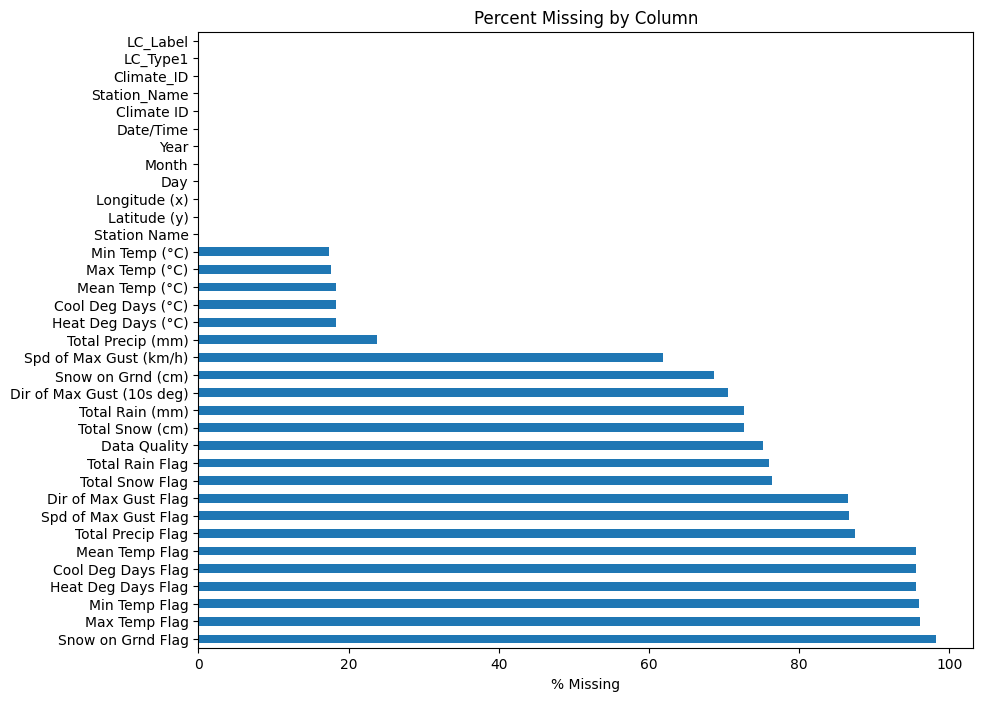

In [ ]:
missing_by_column = LC_weather_merged.isnull().mean().sort_values(ascending=False) * 100
print("Missing data (% by column):")
print(missing_by_column)

# Visualize the percentage of missing data by column
import matplotlib.pyplot as plt

missing_by_column.plot(kind='barh', figsize=(10, 8), title='Percent Missing by Column')
plt.xlabel('% Missing')
plt.show()


# **3.1 Generate & Assess Core Weather Dataset**

## Generate core weather dataset

In [ ]:
# Load weather dataset for reference
import pandas as pd
LC_weather_merged = pd.read_csv('/content/drive/MyDrive/MDP_Capstone_Project/Data/LC_weather_merged.csv')

# Define columns extracted for core weather dataset
weather_core_columns = [
    'Station_Name', 'Latitude (y)', 'Longitude (x)', 'Date/Time', 'LC_Type1', 'LC_Label',
    'Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)', 'Total Precip (mm)'
]

# Create core weather dataset and remove rows with missing data
weather_core = LC_weather_merged[weather_core_columns].dropna()

# Display dataset shape and check first few lines
print(f"Dataset shape after removing missing rows: {weather_core.shape}")
print(weather_core.head())

# Save to Google Drive
weather_core_path = '/content/drive/MyDrive/MDP_Capstone_Project/Data/final_weather_core_cleaned.csv'
weather_core.to_csv(weather_core_path, index=False)
print(f"Core weather dataset saved to: {weather_core_path}")

# Confirm there are no missing values
missing_summary = weather_core.isnull().sum()
print("\nMissing values per column in cleaned core dataset:")
print(missing_summary)

/tmp/ipython-input-2559953931.py:3: DtypeWarning: Columns (3,8,26,28,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  LC_weather_merged = pd.read_csv('/content/drive/MyDrive/MDP Summer Project/Data/LC_weather_merged.csv')


Dataset shape after removing missing rows: (1566193, 10)
   Station_Name  Latitude (y)  Longitude (x)   Date/Time  LC_Type1  \
0         TABER         49.79        -112.12  2024-01-01        13   
1         TABER         49.79        -112.12  2024-01-02        13   
2         TABER         49.79        -112.12  2024-01-03        13   
13        TABER         49.79        -112.12  2024-01-14        13   
14        TABER         49.79        -112.12  2024-01-15        13   

                    LC_Label  Max Temp (°C)  Min Temp (°C)  Mean Temp (°C)  \
0   Urban and Built-up Lands            0.0           -8.0            -4.0   
1   Urban and Built-up Lands            3.0           -8.0            -2.5   
2   Urban and Built-up Lands            6.5           -9.5            -1.5   
13  Urban and Built-up Lands           -8.5          -40.0           -24.3   
14  Urban and Built-up Lands           -6.5          -31.0           -18.8   

    Total Precip (mm)  
0                 0.0  
1    

# **3.2 Generate & Assess Weather with Gust Dataset**

# Generate core weather + wind speed dataset

In [ ]:
# Generate second dataset which includes max wind gust speeds
weather_gust_columns = weather_core_columns + ['Spd of Max Gust (km/h)']
weather_with_gust = LC_weather_merged[weather_gust_columns]

# Count missing gust values
gust_missing_count = weather_with_gust['Spd of Max Gust (km/h)'].isna().sum()
print(f"Missing wind gust entries: {gust_missing_count}")

Missing wind gust entries: 1325899


In [ ]:
# Inspect wind gust column
print(weather_with_gust['Spd of Max Gust (km/h)'].dtype)

# Convert to numeric and check unique entries
invalid_gust_values = weather_with_gust[~pd.to_numeric(weather_with_gust['Spd of Max Gust (km/h)'], errors='coerce').notna()]

# Show unique entries
print(invalid_gust_values['Spd of Max Gust (km/h)'].unique())

(weather_with_gust['Spd of Max Gust (km/h)'] == '<31').sum()

total_non_na = weather_with_gust['Spd of Max Gust (km/h)'].notna().sum()
lt_31_count = (weather_with_gust['Spd of Max Gust (km/h)'] == '<31').sum()
print(f"'<31' count: {lt_31_count}")
print(f"Percentage of non-missing gust entries: {lt_31_count / total_non_na:.2%}")

object
[nan '<31']
'<31' count: 181533
Percentage of non-missing gust entries: 22.22%


### Replace all thresholded values (<31) with average wind speed (i.e., 15 km/h)

In [ ]:
# Make a copy of the weather_with_gust df
weather_with_gust = LC_weather_merged[weather_gust_columns].copy()

# First create flag column for <31 entries
weather_with_gust['gust_flag_threshold'] = weather_with_gust['Spd of Max Gust (km/h)'] == '<31'

# Replace <31 with 15
weather_with_gust.loc[weather_with_gust['gust_flag_threshold'], 'Spd of Max Gust (km/h)'] = 15

# Convert gust column to numeric
weather_with_gust['Spd of Max Gust (km/h)'] = pd.to_numeric(
    weather_with_gust['Spd of Max Gust (km/h)'], errors='coerce'
)

# Check results
print(weather_with_gust['gust_flag_threshold'].sum(), "rows flagged as threshold values.")
print(weather_with_gust['Spd of Max Gust (km/h)'].describe())
print(weather_with_gust)

181533 rows flagged as threshold values.
count    817133.000000
mean         39.265129
std          17.884992
min          13.000000
25%          32.000000
50%          39.000000
75%          49.000000
max         231.000000
Name: Spd of Max Gust (km/h), dtype: float64
           Station_Name  Latitude (y)  Longitude (x)   Date/Time  LC_Type1  \
0                 TABER         49.79        -112.12  2024-01-01        13   
1                 TABER         49.79        -112.12  2024-01-02        13   
2                 TABER         49.79        -112.12  2024-01-03        13   
3                 TABER         49.79        -112.12  2024-01-04        13   
4                 TABER         49.79        -112.12  2024-01-05        13   
...                 ...           ...            ...         ...       ...   
2143027  POWELL RIVER A         49.83        -124.50  2018-12-27         1   
2143028  POWELL RIVER A         49.83        -124.50  2018-12-28         1   
2143029  POWELL RIVER A     

In [ ]:
# Save the processed dataset as CSV to Google Drive
weather_with_gust_path = '/content/drive/MyDrive/MDP_Capstone_Project/Data/weather_with_gust_processed.csv'
weather_with_gust.to_csv(weather_with_gust_path, index=False)

In [ ]:
# CHECK PREIMPUTATION DF
weather_path = '/content/drive/MyDrive/MDP_Capstone_Project/Data/weather_with_gust_processed.csv'
weather_with_gust = pd.read_csv(weather_path)

# Drop any rows with missing values
preweather_clean = weather_with_gust.dropna().copy()

# Check for any remaining missing values
missing_summary = preweather_clean.isna().sum()
print("Remaining missing values per column:")
print(missing_summary[missing_summary > 0])

# Compare dataset shape before and after cleaning
print(f"Original shape: {weather_with_gust.shape}")
print(f"After cleaning: {preweather_clean.shape}")

# Check all other columns for missing values
print("\nRemaining NaNs in other weather variables:")
print(preweather_clean.isna().sum())

# Check counts for imputed and threshold gust values
total_gusts = preweather_clean.shape[0]
num_threshold = preweather_clean['gust_flag_threshold'].sum()

print(f"\nTotal rows: {total_gusts}")
print(f"Number of gusts from threshold values: {num_threshold} ({num_threshold/total_gusts:.2%})")


Remaining missing values per column:
Series([], dtype: int64)
Original shape: (2143032, 12)
After cleaning: (692728, 12)

Remaining NaNs in other weather variables:
Station_Name              0
Latitude (y)              0
Longitude (x)             0
Date/Time                 0
LC_Type1                  0
LC_Label                  0
Max Temp (°C)             0
Min Temp (°C)             0
Mean Temp (°C)            0
Total Precip (mm)         0
Spd of Max Gust (km/h)    0
gust_flag_threshold       0
dtype: int64

Total rows: 692728
Number of gusts from threshold values: 154571 (22.31%)


## **Impute wind gust values**

In [ ]:
# Cascading Distance Spatiotemporal Gust Imputation
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

# Load processed weather dataset
weather_path = '/content/drive/MyDrive/MDP_Capstone_Project/Data/weather_with_gust_processed.csv'
weather_with_gust = pd.read_csv(weather_path)

# Constants
R_KM = 6371.0088  # Earth radius in km
RADIUS_LIST = [5.0, 10.0, 15.0]  # km thresholds (cascade)

# Split known vs unknown gusts
gust_known = weather_with_gust[weather_with_gust['Spd of Max Gust (km/h)'].notna()].copy()
gust_unknown = weather_with_gust[weather_with_gust['Spd of Max Gust (km/h)'].isna()].copy()
print(f"Known gust rows: {gust_known.shape}")
print(f"Unknown gust rows: {gust_unknown.shape}")

# Ensure original gust values are not flagged as imputed values
gust_known['gust_flag_imputed'] = False

# Pre-group donors and recipients by date
known_by_date = {d: df for d, df in gust_known.groupby('Date/Time')}
unknown_by_date = {d: df for d, df in gust_unknown.groupby('Date/Time')}

processed_parts = []

# Loop through dates with missing gusts
for date_i, unk_df in unknown_by_date.items():
    kn_df = known_by_date.get(date_i)
    if kn_df is None or kn_df.empty:
        processed_parts.append(unk_df)  # no donors, keep missing
        continue

    # Build BallTree from known coords (radians)
    kn_coords_rad = np.radians(kn_df[['Latitude (y)', 'Longitude (x)']].to_numpy())
    tree = BallTree(kn_coords_rad, metric='haversine')

    unk_coords_rad = np.radians(unk_df[['Latitude (y)', 'Longitude (x)']].to_numpy())

    # Prepare recipient copy
    tmp = unk_df.copy()
    tmp['gust_flag_imputed'] = False
    tmp['imputed_radius_km'] = 0
    tmp['gust_flag_threshold'] = tmp.get('gust_flag_threshold', False)

    # Cascade through distance thresholds
    for radius in RADIUS_LIST:
        mask_unfilled = ~tmp['gust_flag_imputed']
        if not mask_unfilled.any():
            break  # all rows filled

        coords_subset = unk_coords_rad[mask_unfilled]
        dist_rad, idx = tree.query(coords_subset, k=1, return_distance=True)
        dist_km = dist_rad[:, 0] * R_KM
        nn_idx = idx[:, 0]

        within_radius = dist_km <= radius
        if not within_radius.any():
            continue

        idx_to_update = tmp[mask_unfilled].index[within_radius]
        donor_rows = kn_df.iloc[nn_idx[within_radius]]

        # Assign values
        tmp.loc[idx_to_update, 'Spd of Max Gust (km/h)'] = donor_rows['Spd of Max Gust (km/h)'].to_numpy()
        tmp.loc[idx_to_update, 'gust_flag_imputed'] = True
        tmp.loc[idx_to_update, 'imputed_radius_km'] = radius
        tmp.loc[idx_to_update, 'gust_flag_threshold'] = donor_rows['gust_flag_threshold'].to_numpy()

    processed_parts.append(tmp)

# Recombine all rows
unknown_imputed = pd.concat(processed_parts, axis=0).sort_index()
final = pd.concat([gust_known, unknown_imputed], axis=0).sort_index()

# Ensure flags and radius are proper types
final['gust_flag_imputed'] = final['gust_flag_imputed'].astype(bool)
final['gust_flag_threshold'] = final['gust_flag_threshold'].astype(bool)
final['imputed_radius_km'] = final['imputed_radius_km'].fillna(0).astype(int)

# Summary diagnostics
total_missing_before = gust_unknown.shape[0]
total_imputed = final.loc[gust_unknown.index, 'gust_flag_imputed'].sum()  # only originally missing rows
total_threshold = final['gust_flag_threshold'].sum()

print("\nDiagnostics:")
print(f"Original non-missing gusts (pre-impute): {gust_known.shape[0]}")
print(f"Missing gusts before imputation: {total_missing_before}")
print(f"Imputed successfully: {total_imputed} ({total_imputed/total_missing_before:.2%})")
print(f"Total threshold-flagged gusts (original + imputed): {total_threshold}")
print("\nImputation breakdown by radius (km) for newly imputed rows only:")
print(final.loc[final['gust_flag_imputed'], 'imputed_radius_km'].value_counts().sort_index())

# Save final dataset
output_path = "/content/drive/MyDrive/MDP_Capstone_Project/Data/weather_with_gust_imputed.csv"
final.to_csv(output_path, index=False)


Known gust rows: (817133, 12)
Unknown gust rows: (1325899, 12)

Diagnostics:
Original non-missing gusts (pre-impute): 817133
Missing gusts before imputation: 1325899
Imputed successfully: 293085 (22.10%)
Total threshold-flagged gusts (original + imputed): 275966

Imputation breakdown by radius (km) for newly imputed rows only:
imputed_radius_km
5     121197
10     81435
15     90453
Name: count, dtype: int64


### Verify consistency of dataset before finalizing

In [ ]:
# Check dataset consistency
total_rows = final.shape[0]
original_gusts = gust_known.shape[0]
missing_before = gust_unknown.shape[0]
newly_imputed = final['gust_flag_imputed'].sum()
remaining_missing = missing_before - newly_imputed
threshold_total = final['gust_flag_threshold'].sum()

print("Dataset Checks")
print(f"Total rows in final dataset: {total_rows}")
print(f"Original known (non-missing) gusts: {original_gusts}")
print(f"Missing gusts before imputation: {missing_before}")
print(f"Newly imputed gusts: {newly_imputed}")
print(f"Remaining missing gusts (should equal missing_before - newly_imputed): {remaining_missing}")
print(f"Total threshold-flagged gusts (original + imputed): {threshold_total}")

# Check breakdown of imputed_radius_km
print("\nImputation radius breakdown (0 = original, >0 = imputed):")
print(final['imputed_radius_km'].value_counts().sort_index())


=== Dataset Consistency Check ===
Total rows in final dataset: 2143032
Original known (non-missing) gusts: 817133
Missing gusts before imputation: 1325899
Newly imputed gusts: 293085
Remaining missing gusts (should equal missing_before - newly_imputed): 1032814
Total threshold-flagged gusts (original + imputed): 275966

Imputation radius breakdown (0 = original, >0 = imputed):
imputed_radius_km
0     1849947
5      121197
10      81435
15      90453
Name: count, dtype: int64


### Clean & save the final dataset (cleaned weather df with imputed gusts)

In [ ]:
# Drop any rows with missing values
final_clean = final.dropna().copy()

# Check for any remaining missing values
missing_summary = final_clean.isna().sum()
print("Remaining missing values per column:")
print(missing_summary[missing_summary > 0])

# Compare dataset shape before and after cleaning
print(f"Original shape: {final.shape}")
print(f"After cleaning: {final_clean.shape}")

# Check counts for imputed and threshold gust values
total_gusts = final_clean.shape[0]
num_threshold = final_clean['gust_flag_threshold'].sum()
num_imputed = final_clean['gust_flag_imputed'].sum()

print(f"\nTotal rows: {total_gusts}")
print(f"Number of gusts from threshold values: {num_threshold} ({num_threshold/total_gusts:.2%})")
print(f"Number of gusts that were imputed: {num_imputed} ({num_imputed/total_gusts:.2%})")

# Define output path in your Google Drive
output_path = "/content/drive/MyDrive/MDP_Capstone_Project/Data/final_weather_with_gust_cleaned.csv"

# Save the cleaned dataframe
final_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")


Remaining missing values per column:
Series([], dtype: int64)
Original shape: (2143032, 14)
After cleaning: (875649, 14)

Total rows: 875649
Number of gusts from threshold values: 217243 (24.81%)
Number of gusts that were imputed: 182921 (20.89%)
Cleaned dataset saved to: /content/drive/MyDrive/MDP Summer Project/Data/final_weather_with_gust_cleaned.csv


# **Adjust Column Names for Final Premerge Weather Dataframes**

### Fill in missing station elevation values to enrich final weather datasets

In [ ]:
import pandas as pd
import numpy as np

# First define Alberta/BC station subset
df_ab_bc = df_stations[
    df_stations['Province'].isin(['ALBERTA', 'BRITISH COLUMBIA']) &
    (df_stations['DLY First Year'] <= 2024) &
    (df_stations['DLY Last Year'] >= 2014)
].copy()

# Isolate stations in this subset with missing elevation
missing_elevation_ab_bc = df_ab_bc[df_ab_bc['Elevation (m)'].isna()].copy()

# Check resulting station information
print(f'Stations Missing Elevation: {missing_elevation_ab_bc.shape[0]}')
print(missing_elevation_ab_bc[['Name', 'Province', 'Latitude (Decimal Degrees)', 'Longitude (Decimal Degrees)']])


Stations Missing Elevation: 4
                    Name          Province  Latitude (Decimal Degrees)  \
49            KELP REEFS  BRITISH COLUMBIA                       48.55   
120   VICTORIA HARBOUR A  BRITISH COLUMBIA                       48.42   
1102   VANCOUVER HARBOUR  BRITISH COLUMBIA                       49.29   
2835      SUNNYNOOK AGCM           ALBERTA                       51.30   

      Longitude (Decimal Degrees)  
49                        -123.24  
120                       -123.39  
1102                      -123.11  
2835                      -111.39  


In [ ]:
import requests

# Define function to pull elevation data from NRCan API
def nrcan_elevation(lat, lon, coverage="cdem"):
  url = f"http://geogratis.gc.ca/services/elevation/{coverage}/altitude"
  params = {
      "lat": lat,
      "lon": lon
  }

  try:
      r = requests.get(url, params=params, timeout=10)
      if r.status_code != 200:
          return None

      data = r.json()
      return data.get("altitude", None)

  except Exception:
      return None

In [ ]:
# Use function to request elevation data for missing points
missing_elevation_ab_bc['Elevation_filled_m'] = np.nan

for idx, row in missing_elevation_ab_bc.iterrows():
  lat = row['Latitude (Decimal Degrees)']
  lon = row['Longitude (Decimal Degrees)']

  elev = nrcan_elevation(lat, lon)
  missing_elevation_ab_bc.at[idx, 'Elevation_filled_m'] = elev

# Check success
print(missing_elevation_ab_bc['Elevation_filled_m'].describe())
print("Still missing after API:", missing_elevation_ab_bc['Elevation_filled_m'].isna().sum())

count      4.00
mean     193.75
std      387.50
min        0.00
25%        0.00
50%        0.00
75%      193.75
max      775.00
Name: Elevation_filled_m, dtype: float64
Still missing after API: 0


In [ ]:
df_ab_bc.head()

,Name,Province,Climate ID,Station ID,WMO ID,TC ID,Latitude (Decimal Degrees),Longitude (Decimal Degrees),Latitude,Longitude,Elevation (m),First Year,Last Year,HLY First Year,HLY Last Year,DLY First Year,DLY Last Year,MLY First Year,MLY Last Year
12,CHEMAINUS,BRITISH COLUMBIA,1011500,26,NaN,NaN,48.94,-123.74,485606080,-1234430000,75.00,1919,2024,NaN,NaN,1919.0,2024.0,1919.0,2007.0
23,COWICHAN LAKE FORESTRY,BRITISH COLUMBIA,1012040,37,NaN,NaN,48.82,-124.13,484928000,-1240800000,176.80,1949,2018,NaN,NaN,1949.0,2018.0,1949.0,2007.0
26,LAKE COWICHAN,BRITISH COLUMBIA,1012055,40,NaN,NaN,48.83,-124.05,484946000,-1240308000,171.00,1960,2025,NaN,NaN,1960.0,2025.0,1960.0,2007.0
28,DISCOVERY ISLAND,BRITISH COLUMBIA,1012475,27226,71031.0,WDR,48.42,-123.23,482528590,-1231332519,18.93,1997,2025,1997.0,2025.0,1997.0,2025.0,1998.0,2005.0
33,DUNCAN KELVIN CREEK,BRITISH COLUMBIA,1012573,46,NaN,NaN,48.73,-123.73,484405000,-1234339001,103.00,1987,2016,NaN,NaN,1987.0,2016.0,1987.0,2007.0


In [ ]:
missing_elevation_ab_bc.head()

,Name,Province,Climate ID,Station ID,WMO ID,TC ID,Latitude (Decimal Degrees),Longitude (Decimal Degrees),Latitude,Longitude,Elevation (m),First Year,Last Year,HLY First Year,HLY Last Year,DLY First Year,DLY Last Year,MLY First Year,MLY Last Year,Elevation_filled_m
49,KELP REEFS,BRITISH COLUMBIA,1013998,10853,NaN,WZO,48.55,-123.24,483251700,-1231413320,NaN,1997,2025,1997.0,2025.0,2018.0,2025.0,NaN,NaN,0.0
120,VICTORIA HARBOUR A,BRITISH COLUMBIA,1018633,53479,NaN,YWH,48.42,-123.39,482522000,-1232315000,NaN,2015,2025,2015.0,2025.0,2018.0,2025.0,NaN,NaN,0.0
1102,VANCOUVER HARBOUR,BRITISH COLUMBIA,110Q44V,55438,NaN,YHC,49.29,-123.11,491740000,-1230641000,NaN,2023,2025,2023.0,2025.0,2023.0,2025.0,NaN,NaN,0.0
2835,SUNNYNOOK AGCM,ALBERTA,3026264,53100,NaN,PNU,51.30,-111.39,511803010,-1112317030,NaN,2014,2024,2014.0,2024.0,2018.0,2024.0,NaN,NaN,775.0


### Merge filled values into AB/BC station subset

In [ ]:
# Merge filled elevation values
df_ab_bc_filled = df_ab_bc.merge(
    missing_elevation_ab_bc[['Name', 'Elevation_filled_m']],
    on='Name',
    how='left'
)

# Add filled values into original elevation column
df_ab_bc_filled['Elevation_Final_m'] = df_ab_bc_filled['Elevation (m)'].fillna(df_ab_bc_filled['Elevation_filled_m'])

# Check
print(df_ab_bc_filled[['Name', 'Elevation (m)', 'Elevation_Final_m']])

print("Missing Elevation Values:", df_ab_bc_filled['Elevation_Final_m'].isna().sum())

                       Name  Elevation (m)  Elevation_Final_m
0                 CHEMAINUS          75.00              75.00
1    COWICHAN LAKE FORESTRY         176.80             176.80
2             LAKE COWICHAN         171.00             171.00
3          DISCOVERY ISLAND          18.93              18.93
4       DUNCAN KELVIN CREEK         103.00             103.00
..                      ...            ...                ...
648         VALLEYVIEW AGDM         698.00             698.00
649            GARDEN RIVER         240.80             240.80
650             COLD LAKE A         541.00             541.00
651              DUPRE AGCM         556.00             556.00
652          BEAVERDAM AGCM         592.00             592.00

[653 rows x 3 columns]
Missing Elevation Values: 0


In [ ]:
# Drop extra elevation columns and rename for clarity
df_ab_bc_filled = df_ab_bc_filled.drop(columns=['Elevation (m)', 'Elevation_filled_m'])
df_ab_bc_filled = df_ab_bc_filled.rename(columns={'Elevation_Final_m': 'Elevation_m'})


In [ ]:
print("Missing Elevation Values:", df_ab_bc_filled['Elevation_m'].isna().sum())
print(df_ab_bc_filled.columns)
df_ab_bc_filled.head()

Missing Elevation Values: 0
Index(['Name', 'Province', 'Climate ID', 'Station ID', 'WMO ID', 'TC ID',
       'Latitude (Decimal Degrees)', 'Longitude (Decimal Degrees)', 'Latitude',
       'Longitude', 'First Year', 'Last Year', 'HLY First Year',
       'HLY Last Year', 'DLY First Year', 'DLY Last Year', 'MLY First Year',
       'MLY Last Year', 'Elevation_m'],
      dtype='object')


,Name,Province,Climate ID,Station ID,WMO ID,TC ID,Latitude (Decimal Degrees),Longitude (Decimal Degrees),Latitude,Longitude,First Year,Last Year,HLY First Year,HLY Last Year,DLY First Year,DLY Last Year,MLY First Year,MLY Last Year,Elevation_m
0,CHEMAINUS,BRITISH COLUMBIA,1011500,26,NaN,NaN,48.94,-123.74,485606080,-1234430000,1919,2024,NaN,NaN,1919.0,2024.0,1919.0,2007.0,75.00
1,COWICHAN LAKE FORESTRY,BRITISH COLUMBIA,1012040,37,NaN,NaN,48.82,-124.13,484928000,-1240800000,1949,2018,NaN,NaN,1949.0,2018.0,1949.0,2007.0,176.80
2,LAKE COWICHAN,BRITISH COLUMBIA,1012055,40,NaN,NaN,48.83,-124.05,484946000,-1240308000,1960,2025,NaN,NaN,1960.0,2025.0,1960.0,2007.0,171.00
3,DISCOVERY ISLAND,BRITISH COLUMBIA,1012475,27226,71031.0,WDR,48.42,-123.23,482528590,-1231332519,1997,2025,1997.0,2025.0,1997.0,2025.0,1998.0,2005.0,18.93
4,DUNCAN KELVIN CREEK,BRITISH COLUMBIA,1012573,46,NaN,NaN,48.73,-123.73,484405000,-1234339001,1987,2016,NaN,NaN,1987.0,2016.0,1987.0,2007.0,103.00


In [ ]:
# Save the cleaned station metadata as csv
df_ab_bc_filled.to_csv(
    '/content/drive/MyDrive/MDP_Capstone_Project/Data/final_station_metadata_ab_bc.csv',
    index=False)

# **Load Weather Core & Weather Core + Gust Dataframes for final adjustments**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Load both cleaned datasets + metadata
weather_core = pd.read_csv('/content/drive/MyDrive/MDP_Capstone_Project/Data/final_weather_core_cleaned.csv')
weather_gust = pd.read_csv('/content/drive/MyDrive/MDP_Capstone_Project/Data/final_weather_with_gust_cleaned.csv')
station_metadata = pd.read_csv('/content/drive/MyDrive/MDP_Capstone_Project/Data/final_station_metadata_ab_bc.csv')

# Check stations names are identical for merging
print("Unique stations in weather_core:", weather_core['Station_Name'].nunique())
print("Unique stations in station_metadata:", station_metadata['Name'].nunique())

missing_stations = set(weather_core['Station_Name']) - set(station_metadata['Name'])
print("Stations in weather_core not in metadata:", len(missing_stations))

Mounted at /content/drive
Unique stations in weather_core: 578
Unique stations in station_metadata: 629
Stations in weather_core not in metadata: 0


### Add climate ID back into core and gust datasets before merge to ensure proper merge key exists

In [ ]:
# Load previous df with Climate ID variable as source
id_source = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/LC_weather_merged.csv",
    low_memory=False)

# Standardize columns of interest
id_source['Station Name'] = id_source['Station Name'].astype(str).str.strip()
id_source['Climate ID'] = id_source['Climate ID'].astype(str).str.strip()
station_metadata['Climate ID'] = station_metadata['Climate ID'].astype(str).str.strip()

weather_core['Station_Name'] = weather_core['Station_Name'].astype(str).str.strip()
weather_gust['Station_Name'] = weather_gust['Station_Name'].astype(str).str.strip()

# Create table to map (Station Name, Lat, Long) to Climate ID
counts = (
    id_source[['Station Name','Latitude (y)','Longitude (x)','Climate ID']]
    .dropna()
    .assign(n=1)
    .groupby(['Station Name','Latitude (y)','Longitude (x)','Climate ID'], as_index=False)['n'].sum()
)

# Identify conflicts
conflict_keys = counts[counts.duplicated(subset=['Station Name','Latitude (y)','Longitude (x)'], keep=False)]
print(f"Conflicting (Station Name, Lat, Lon) keys: {conflict_keys[['Station Name','Latitude (y)','Longitude (x)']].drop_duplicates().shape[0]}")

# Resolve by picking Climate ID with max count for each key
lookup = (
    counts.sort_values(['Station Name','Latitude (y)','Longitude (x)','n'], ascending=[True, True, True, False])
    .drop_duplicates(subset=['Station Name','Latitude (y)','Longitude (x)'])
    [['Station Name','Latitude (y)','Longitude (x)','Climate ID']]
)

# Check lookup is one-to-one
dup_lookup = lookup.duplicated(subset=['Station Name','Latitude (y)','Longitude (x)']).sum()

if dup_lookup == 0:
    print("Lookup is one-to-one.")
else:
    print(f"Lookup has {dup_lookup} duplicate keys.")

# Save table with conflicts for reference if needed
conflict_table = conflict_keys.sort_values(['Station Name','Latitude (y)','Longitude (x)','n'], ascending=[True, True, True, False])
conflict_table.to_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/station_climateid_conflicts.csv", index=False)

Conflicting (Station Name, Lat, Lon) keys: 17
Lookup is one-to-one.


### Merge Climate ID back into weather_core and weather_gust

In [ ]:
core_before = weather_core.shape[0]
gust_before = weather_gust.shape[0]

weather_core2 = weather_core.merge(
    lookup,
    left_on=['Station_Name','Latitude (y)','Longitude (x)'],
    right_on=['Station Name','Latitude (y)','Longitude (x)'],
    how='left'
).drop(columns=['Station Name'])

weather_gust2 = weather_gust.merge(
    lookup,
    left_on=['Station_Name','Latitude (y)','Longitude (x)'],
    right_on=['Station Name','Latitude (y)','Longitude (x)'],
    how='left'
).drop(columns=['Station Name'])

print("Core rows before/after Climate ID merge:", core_before, weather_core2.shape[0])
print("Gust rows before/after Climate ID merge:", gust_before, weather_gust2.shape[0])

# Check for missing Climate IDs after merge
print("Missing Climate ID in core after merge:", weather_core2['Climate ID'].isna().sum())
print("Missing Climate ID in gust after merge:", weather_gust2['Climate ID'].isna().sum())


Core rows before/after Climate ID merge: 1566193 1566193
Gust rows before/after Climate ID merge: 875649 875649
Missing Climate ID in core after merge: 0
Missing Climate ID in gust after merge: 0


### Now merge metadata using Climate ID

In [ ]:
# Climate ID successfully added to weather_core and weather_gust
# Now save the updated dataframes
weather_core = weather_core2
weather_gust = weather_gust2

# Perform metadata merge to add province and elevation
# Standardize Climate ID strings
weather_core['Climate ID'] = weather_core['Climate ID'].astype(str).str.strip()
weather_gust['Climate ID'] = weather_gust['Climate ID'].astype(str).str.strip()
station_metadata['Climate ID'] = station_metadata['Climate ID'].astype(str).str.strip()

core_before_meta = weather_core.shape[0]
gust_before_meta = weather_gust.shape[0]

weather_core2 = weather_core.merge(
    station_metadata[['Climate ID','Province','Elevation_m']],
    on='Climate ID',
    how='left'
)

weather_gust2 = weather_gust.merge(
    station_metadata[['Climate ID','Province','Elevation_m']],
    on='Climate ID',
    how='left'
)

print("Core rows before/after metadata merge:", core_before_meta, weather_core2.shape[0])
print("Gust rows before/after metadata merge:", gust_before_meta, weather_gust2.shape[0])

print("Core missing Province/Elevation:", weather_core2[['Province','Elevation_m']].isna().sum().to_dict())
print("Gust missing Province/Elevation:", weather_gust2[['Province','Elevation_m']].isna().sum().to_dict())


Core rows before/after metadata merge: 1566193 1566193
Gust rows before/after metadata merge: 875649 875649
Core missing Province/Elevation: {'Province': 0, 'Elevation_m': 0}
Gust missing Province/Elevation: {'Province': 0, 'Elevation_m': 0}


In [ ]:
# Merge successfully completed: save updated dataframes
weather_core = weather_core2
weather_gust = weather_gust2

### Check for duplicate station, coordinate, and date records

In [ ]:
# Check duplicates at the row level (station+coords+date should be unique)
core_dups = weather_core.duplicated(subset=['Station_Name','Latitude (y)','Longitude (x)','Date/Time']).sum()
gust_dups = weather_gust.duplicated(subset=['Station_Name','Latitude (y)','Longitude (x)','Date/Time']).sum()

print("Duplicate rows in core (station+coords+date):", core_dups)
print("Duplicate rows in gust (station+coords+date):", gust_dups)

Duplicate rows in core (station+coords+date): 5573
Duplicate rows in gust (station+coords+date): 4750


In [ ]:
core_dups_id = weather_core.duplicated(subset=['Climate ID', 'Date/Time']).sum()
gust_dups_id = weather_gust.duplicated(subset=['Climate ID', 'Date/Time']).sum()

print("Duplicates in core on (Climate ID, Date):", core_dups_id)
print("Duplicates in gust on (Climate ID, Date):", gust_dups_id)

Duplicates in core on (Climate ID, Date): 5573
Duplicates in gust on (Climate ID, Date): 4750


In [ ]:
# Check size of duplicates
print("Core duplicate rate:", 5573 / len(weather_core))
print("Gust duplicate rate:", 4750 / len(weather_gust))

# Manually check a few duplicates
dup_core = weather_core[weather_core.duplicated(['Climate ID','Date/Time'], keep=False)] \
    .sort_values(['Climate ID','Date/Time'])
dup_core.head(100)

Core duplicate rate: 0.003558309863471488
Gust duplicate rate: 0.005424547963853096


,Station_Name,Latitude (y),Longitude (x),Date/Time,LC_Type1,LC_Label,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Total Precip (mm),Climate ID,Province,Elevation_m
1442332,ENTRANCE ISLAND,49.21,-123.81,2014-01-01,17,Water Bodies,7.2,6.1,6.7,1.2,1022689,BRITISH COLUMBIA,7.6
1476614,ENTRANCE ISLAND,49.21,-123.81,2014-01-01,17,Water Bodies,7.5,6.0,6.8,1.2,1022689,BRITISH COLUMBIA,7.6
1442333,ENTRANCE ISLAND,49.21,-123.81,2014-01-02,17,Water Bodies,8.5,6.1,7.3,3.6,1022689,BRITISH COLUMBIA,7.6
1476615,ENTRANCE ISLAND,49.21,-123.81,2014-01-02,17,Water Bodies,8.0,6.5,7.3,4.4,1022689,BRITISH COLUMBIA,7.6
1442334,ENTRANCE ISLAND,49.21,-123.81,2014-01-03,17,Water Bodies,7.1,5.9,6.5,0.0,1022689,BRITISH COLUMBIA,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476705,ENTRANCE ISLAND,49.21,-123.81,2014-04-03,17,Water Bodies,9.0,8.0,8.5,3.2,1022689,BRITISH COLUMBIA,7.6
1442380,ENTRANCE ISLAND,49.21,-123.81,2014-04-04,17,Water Bodies,11.0,7.4,9.2,1.0,1022689,BRITISH COLUMBIA,7.6
1476706,ENTRANCE ISLAND,49.21,-123.81,2014-04-04,17,Water Bodies,11.0,7.0,9.0,1.4,1022689,BRITISH COLUMBIA,7.6
1442381,ENTRANCE ISLAND,49.21,-123.81,2014-04-05,17,Water Bodies,8.8,6.1,7.5,0.4,1022689,BRITISH COLUMBIA,7.6


In [ ]:
# Manually check a few duplicates
dup_gust = weather_gust[weather_gust.duplicated(['Climate ID','Date/Time'], keep=False)] \
    .sort_values(['Climate ID','Date/Time'])
dup_gust.head(50)

,Station_Name,Latitude (y),Longitude (x),Date/Time,LC_Type1,LC_Label,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Total Precip (mm),Spd of Max Gust (km/h),gust_flag_threshold,gust_flag_imputed,imputed_radius_km,Climate ID,Province,Elevation_m
829582,ENTRANCE ISLAND,49.21,-123.81,2014-01-01,17,Water Bodies,7.2,6.1,6.7,1.2,15.0,True,False,0,1022689,BRITISH COLUMBIA,7.6
847011,ENTRANCE ISLAND,49.21,-123.81,2014-01-01,17,Water Bodies,7.5,6.0,6.8,1.2,15.0,True,True,5,1022689,BRITISH COLUMBIA,7.6
829583,ENTRANCE ISLAND,49.21,-123.81,2014-01-02,17,Water Bodies,8.5,6.1,7.3,3.6,80.0,False,False,0,1022689,BRITISH COLUMBIA,7.6
847012,ENTRANCE ISLAND,49.21,-123.81,2014-01-02,17,Water Bodies,8.0,6.5,7.3,4.4,80.0,False,True,5,1022689,BRITISH COLUMBIA,7.6
829584,ENTRANCE ISLAND,49.21,-123.81,2014-01-03,17,Water Bodies,7.1,5.9,6.5,0.0,67.0,False,False,0,1022689,BRITISH COLUMBIA,7.6
847013,ENTRANCE ISLAND,49.21,-123.81,2014-01-03,17,Water Bodies,7.0,4.5,5.8,0.0,67.0,False,True,5,1022689,BRITISH COLUMBIA,7.6
829585,ENTRANCE ISLAND,49.21,-123.81,2014-01-07,17,Water Bodies,6.9,4.4,5.7,1.0,39.0,False,False,0,1022689,BRITISH COLUMBIA,7.6
847016,ENTRANCE ISLAND,49.21,-123.81,2014-01-07,17,Water Bodies,7.0,4.5,5.8,3.2,39.0,False,True,5,1022689,BRITISH COLUMBIA,7.6
829586,ENTRANCE ISLAND,49.21,-123.81,2014-01-09,17,Water Bodies,8.1,5.3,6.7,0.4,74.0,False,False,0,1022689,BRITISH COLUMBIA,7.6
847018,ENTRANCE ISLAND,49.21,-123.81,2014-01-09,17,Water Bodies,7.5,5.5,6.5,1.2,74.0,False,True,5,1022689,BRITISH COLUMBIA,7.6


### Fix duplicated date records

In [ ]:
# Fix duplicated records on the same day for weather_core
key = ['Climate ID', 'Date/Time']
core_before = len(weather_core)

core_predictors = ['Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)', 'Total Precip (mm)']
weather_core['_complete'] = weather_core[core_predictors].notna().sum(axis=1)

weather_core = (
    weather_core
    .sort_values(
        key + ['_complete', 'Total Precip (mm)'],
        ascending=[True, True, False, False]
    )
    .drop_duplicates(subset=key, keep='first')
    .drop(columns=['_complete'])
)

print("Core rows removed:", core_before - len(weather_core))

Core rows removed: 5573


In [ ]:
# Fix duplicated records on the same day for weather_gust
key = ['Climate ID', 'Date/Time']
gust_before = len(weather_gust)

gust_predictors = [
    'Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)',
    'Total Precip (mm)', 'Spd of Max Gust (km/h)'
]
weather_gust['_complete'] = weather_gust[gust_predictors].notna().sum(axis=1)

weather_gust = (
    weather_gust
    .sort_values(
        key + ['_complete', 'Total Precip (mm)'],
        ascending=[True, True, False, False]
    )
    .drop_duplicates(subset=key, keep='first')
    .drop(columns=['_complete'])
)

print("Gust rows removed:", gust_before - len(weather_gust))

Gust rows removed: 4750


In [ ]:
# Double check to ensure no duplicates after fix
print("Core duplicates:", weather_core.duplicated(['Climate ID','Date/Time']).sum())
print("Gust duplicates:", weather_gust.duplicated(['Climate ID','Date/Time']).sum())

Core duplicates: 0
Gust duplicates: 0


### Complete final consistency checks

In [ ]:
# Row/Column Missingness Checks

# Check no rows with missing values
print("Rows with any missing values (core):",
      weather_core.isna().any(axis=1).sum())
print("Rows with any missing values (gust):",
      weather_gust.isna().any(axis=1).sum())

# Check no columns with missing values
print("Columns with any missing values (core):",
      weather_core.isna().sum())
print("Columns with any missing values (gust):",
      weather_gust.isna().sum())

Rows with any missing values (core): 0
Rows with any missing values (gust): 0
Columns with any missing values (core): Station_Name         0
Latitude (y)         0
Longitude (x)        0
Date/Time            0
LC_Type1             0
LC_Label             0
Max Temp (°C)        0
Min Temp (°C)        0
Mean Temp (°C)       0
Total Precip (mm)    0
Climate ID           0
Province             0
Elevation_m          0
dtype: int64
Columns with any missing values (gust): Station_Name              0
Latitude (y)              0
Longitude (x)             0
Date/Time                 0
LC_Type1                  0
LC_Label                  0
Max Temp (°C)             0
Min Temp (°C)             0
Mean Temp (°C)            0
Total Precip (mm)         0
Spd of Max Gust (km/h)    0
gust_flag_threshold       0
gust_flag_imputed         0
imputed_radius_km         0
Climate ID                0
Province                  0
Elevation_m               0
dtype: int64


In [ ]:
# Duplicate Checks
print("\nDuplicate ENTIRE rows (core):", weather_core.duplicated().sum())
print("Duplicate ENTIRE rows (gust):", weather_gust.duplicated().sum())

print("\nDuplicate (Climate ID, Date/Time) rows (core):",
      weather_core.duplicated(['Climate ID','Date/Time']).sum())
print("Duplicate (Climate ID, Date/Time) rows (gust):",
      weather_gust.duplicated(['Climate ID','Date/Time']).sum())


Duplicate ENTIRE rows (core): 0
Duplicate ENTIRE rows (gust): 0

Duplicate (Climate ID, Date/Time) rows (core): 0
Duplicate (Climate ID, Date/Time) rows (gust): 0


In [ ]:
# Data Type Checks
print("\nDtypes (core):")
print(weather_core.dtypes)

print("\nDtypes (gust):")
print(weather_gust.dtypes)

# Gust-specific checks (only run if columns exist)
if 'gust_flag_threshold' in weather_gust.columns:
    non_bool_thresh = (~weather_gust['gust_flag_threshold'].isin([True, False])).sum()
    print("\nNon-boolean values in gust_flag_threshold:", non_bool_thresh)

if 'gust_flag_imputed' in weather_gust.columns:
    non_bool_imputed = (~weather_gust['gust_flag_imputed'].isin([True, False])).sum()
    print("Non-boolean values in gust_flag_imputed:", non_bool_imputed)

if 'imputed_radius_km' in weather_gust.columns:
    # Check integer-like (allows 0,5,10,15 stored as float)
    vals = pd.to_numeric(weather_gust['imputed_radius_km'], errors='coerce')
    non_int_like = (vals.dropna() % 1 != 0).sum()
    print("Non-integer-like values in imputed_radius_km:", non_int_like)

    # Optional: check allowed set (0=original, 5/10/15=imputed radii)
    allowed = {0, 5, 10, 15}
    invalid = (~vals.isin(list(allowed))).sum()
    print("Invalid imputed_radius_km values (not in {0,5,10,15}):", invalid)


Dtypes (core):
Station_Name                 object
Province                     object
Climate_ID                   object
Elevation_m                 float64
Latitude_Weather            float64
Longitude_Weather           float64
Date                 datetime64[ns]
LC_Type1                      int64
LC_Label                     object
Max_Temp_C                  float64
Min_Temp_C                  float64
Mean_Temp_C                 float64
Total_Precip_mm             float64
dtype: object

Dtypes (gust):
Station_Name                   object
Province                       object
Climate_ID                     object
Elevation_m                   float64
Latitude_Weather              float64
Longitude_Weather             float64
Date                   datetime64[ns]
LC_Type1                        int64
LC_Label                       object
Max_Temp_C                    float64
Min_Temp_C                    float64
Mean_Temp_C                   float64
Total_Precip_mm               

In [ ]:
# Adjust date/time and Climate ID
weather_core['Date/Time'] = pd.to_datetime(weather_core['Date/Time'])
weather_gust['Date/Time'] = pd.to_datetime(weather_gust['Date/Time'])

weather_core['Climate ID'] = weather_core['Climate ID'].astype(str).str.strip()
weather_gust['Climate ID'] = weather_gust['Climate ID'].astype(str).str.strip()

In [ ]:
# Climate ID Checks

# (1) Check if Climate ID maps to one Station_Name
core_idname_check = (weather_core.groupby('Climate ID')['Station_Name'].nunique() > 1).sum()
gust_idname_check = (weather_gust.groupby('Climate ID')['Station_Name'].nunique() > 1).sum()

print("\nClimate IDs mapping to >1 Station Name (core):", core_idname_check)
print("Climate IDs mapping to >1 Station Name (gust):", gust_idname_check)

# (2) Check if Climate ID maps to one coordinate set
core_idcoord_check = (
    weather_core.groupby('Climate ID')[['Latitude (y)', 'Longitude (x)']].nunique().gt(1).any(axis=1).sum()
)

gust_idcoord_check = (
    weather_gust.groupby('Climate ID')[['Latitude (y)', 'Longitude (x)']].nunique().gt(1).any(axis=1).sum()
)

print("\nClimate IDs mapping to >1 coordinate pair (core):", core_idcoord_check)
print("Climate IDs mapping to >1 coordinate pair (gust):", gust_idcoord_check)


Climate IDs mapping to >1 Station Name (core): 0
Climate IDs mapping to >1 Station Name (gust): 0

Climate IDs mapping to >1 coordinate pair (core): 0
Climate IDs mapping to >1 coordinate pair (gust): 0


### Adjust column names

In [ ]:
# Rename columns for consistency
rename_cols = {
    'Latitude (y)': 'Latitude_Weather',
    'Longitude (x)': 'Longitude_Weather',
    'Date/Time': 'Date',
    'Climate ID': 'Climate_ID',
    'Max Temp (°C)': 'Max_Temp_C',
    'Min Temp (°C)': 'Min_Temp_C',
    'Mean Temp (°C)': 'Mean_Temp_C',
    'Total Precip (mm)': 'Total_Precip_mm',
    'Spd of Max Gust (km/h)': 'Max_Gust_Speed_kmh',
    'gust_flag_threshold': 'Gust_Flag_Threshold',
    'gust_flag_imputed': 'Gust_Flag_Imputed',
    'imputed_radius_km': 'Imputed_Radius_km'
}

weather_core = weather_core.rename(columns=rename_cols)
weather_gust = weather_gust.rename(columns=rename_cols)

# Check column names after change
print(weather_core.columns)
print(weather_gust.columns)

Index(['Station_Name', 'Latitude_Weather', 'Longitude_Weather', 'Date',
       'LC_Type1', 'LC_Label', 'Max_Temp_C', 'Min_Temp_C', 'Mean_Temp_C',
       'Total_Precip_mm', 'Climate_ID', 'Province', 'Elevation_m'],
      dtype='object')
Index(['Station_Name', 'Latitude_Weather', 'Longitude_Weather', 'Date',
       'LC_Type1', 'LC_Label', 'Max_Temp_C', 'Min_Temp_C', 'Mean_Temp_C',
       'Total_Precip_mm', 'Max_Gust_Speed_kmh', 'Gust_Flag_Threshold',
       'Gust_Flag_Imputed', 'Imputed_Radius_km', 'Climate_ID', 'Province',
       'Elevation_m'],
      dtype='object')


In [ ]:
# Reorder weather_core
weather_core = weather_core[
    [
        'Station_Name', 'Province', 'Climate_ID', 'Elevation_m',
        'Latitude_Weather', 'Longitude_Weather', 'Date',
        'LC_Type1', 'LC_Label',
        'Max_Temp_C', 'Min_Temp_C', 'Mean_Temp_C', 'Total_Precip_mm'
    ]
]

# Reorder weather_gust
weather_gust = weather_gust[
    [
        'Station_Name', 'Province', 'Climate_ID', 'Elevation_m',
        'Latitude_Weather', 'Longitude_Weather', 'Date',
        'LC_Type1', 'LC_Label',
        'Max_Temp_C', 'Min_Temp_C', 'Mean_Temp_C', 'Total_Precip_mm',
        'Max_Gust_Speed_kmh', 'Gust_Flag_Threshold', 'Gust_Flag_Imputed', 'Imputed_Radius_km'
    ]
]

In [ ]:
print("Final missing rows (core):",
      weather_core.isna().any(axis=1).sum())
print("Final missing rows (gust):",
      weather_gust.isna().any(axis=1).sum())

print("\nFinal duplicate (Climate_ID, Date) rows (core):",
      weather_core.duplicated(['Climate_ID','Date']).sum())
print("Final duplicate (Climate_ID, Date) rows (gust):",
      weather_gust.duplicated(['Climate_ID','Date']).sum())

Final missing rows (core): 0
Final missing rows (gust): 0

Final duplicate (Climate_ID, Date) rows (core): 0
Final duplicate (Climate_ID, Date) rows (gust): 0


In [ ]:
weather_core.shape

(1560620, 13)

In [ ]:
weather_gust.shape

(870899, 17)

In [ ]:
# Save cleaned weather core and weather gust datasets to csv
weather_core.to_csv(
    '/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Weather_Core_LC_Dataset.csv',
    index=False)

weather_gust.to_csv(
    '/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Weather_Gust_LC_Dataset.csv',
    index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

core = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Weather_Core_LC_Dataset.csv")
gust = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Weather_Gust_LC_Dataset.csv")

Mounted at /content/drive


/tmp/ipython-input-1406868236.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  core = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Weather_Core_LC_Dataset.csv")
/tmp/ipython-input-1406868236.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  gust = pd.read_csv("/content/drive/MyDrive/MDP_Capstone_Project/Data/Final_Weather_Gust_LC_Dataset.csv")


In [ ]:
# Check date
core["Date_check"] = pd.to_datetime(core["Date"], errors="coerce")
gust["Date_check"] = pd.to_datetime(gust["Date"], errors="coerce")

print("Unreadable core dates:", core["Date_check"].isna().sum())
print("Unreadable gust dates:", gust["Date_check"].isna().sum())

# Check coverage
print("Core date range:",
      core["Date_check"].min(),
      core["Date_check"].max())

print("Gust date range:",
      gust["Date_check"].min(),
      gust["Date_check"].max())

# Check coordinate range
print("Latitude range (core):",
      core["Latitude_Weather"].min(),
      core["Latitude_Weather"].max())

print("Longitude range (core):",
      core["Longitude_Weather"].min(),
      core["Longitude_Weather"].max())

print("Latitude range (gust):",
      gust["Latitude_Weather"].min(),
      gust["Latitude_Weather"].max())

print("Longitude range (gust):",
      gust["Longitude_Weather"].min(),
      gust["Longitude_Weather"].max())

Unreadable core dates: 0
Unreadable gust dates: 0
Core date range: 2014-01-01 00:00:00 2024-12-31 00:00:00
Gust date range: 2014-01-01 00:00:00 2024-12-31 00:00:00
Latitude range (core): 48.34 59.57
Longitude range (core): -136.37 -110.03
Latitude range (gust): 48.34 58.84
Longitude range (gust): -133.06 -110.03


In [ ]:
print("\nDtypes (core):")
print(core.dtypes)

print("\nDtypes (gust):")
print(gust.dtypes)


Dtypes (core):
Station_Name          object
Province              object
Climate_ID            object
Elevation_m          float64
Latitude_Weather     float64
Longitude_Weather    float64
Date                  object
LC_Type1               int64
LC_Label              object
Max_Temp_C           float64
Min_Temp_C           float64
Mean_Temp_C          float64
Total_Precip_mm      float64
dtype: object

Dtypes (gust):
Station_Name            object
Province                object
Climate_ID              object
Elevation_m            float64
Latitude_Weather       float64
Longitude_Weather      float64
Date                    object
LC_Type1                 int64
LC_Label                object
Max_Temp_C             float64
Min_Temp_C             float64
Mean_Temp_C            float64
Total_Precip_mm        float64
Max_Gust_Speed_kmh     float64
Gust_Flag_Threshold       bool
Gust_Flag_Imputed         bool
Imputed_Radius_km        int64
dtype: object
